Sales Summary:
    product  total_qty  revenue
0    Apples         25     12.5
1   Bananas         45     13.5
2  Cherries         15     15.0


<Figure size 800x500 with 0 Axes>

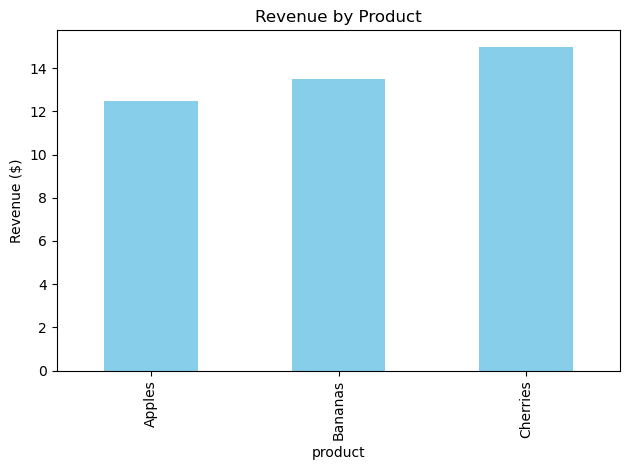

In [1]:


import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL
)
""")


cursor.execute("DELETE FROM sales")


sample_data = [
    ("Apples", 10, 0.5),
    ("Bananas", 20, 0.3),
    ("Cherries", 5, 1.0),
    ("Apples", 15, 0.5),
    ("Bananas", 25, 0.3),
    ("Cherries", 10, 1.0),
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()


query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

print("Sales Summary:")
print(df)


plt.figure(figsize=(8, 5))
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")

plt.tight_layout()

# 5. Show or save the chart
plt.savefig("sales_chart.png")
plt.show()


conn.close()
